# PPP online tool (simplified version of PPP)

- The tool is the simplified version of full PPP. 
- This tool is used to help PFS users know the expected completeness rates and fiber usage fractions of their samples in the proposal prepation phase. 
    - input: sample list (csv/ecsv/fits format) 
        - should include 'obj_id' 'ra' 'dec' 'equinox' 'priority' 'effective_exp' 'resolution' 'comment'
            - priority: int number, from 9 - 0; 0 means highest and 9 means lowest
                - shall we make it float number?
            - ra&dec: can be in degree or (hms,dms)
    - output: 
        - fiber hour & hour required 
        - completeness vs. PPC (PFS pointing center; PPC is sorted by its total priority)
        - fiber usage fraction
    - note:
        - overheads have not been included yet
        - for some dense samples, 
            - it would take very long time to get the ouputs ($\gtrsim$5 min)
            - it may not achieve 100% completion rate due to none fiber-assignment of netflow (need to be fixed)
        - some functions have not been considered:
            - the optimized weighting parameters (conta,b&c) are taken from the simulation / last semester, they are not optimized for the input program in this tool
                - the output total observation time can be longer or shorter than that in the final observation
                - need to check the discrepancy between the time estimated in the tool and the full PPP
            - collision of fibers is not checked & corrected in this tool, as it will take a lot of time
                - for very dense sample (criteria? e.g., cluster candidates), should be careful 
                - need to check the effect of collision of fibers quantitively

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import seaborn as sns
import colorcet as cc
import collections
import sys
import multiprocessing
import psutil

from IPython.display import clear_output
from matplotlib.path import Path
from astropy import units as u
from astropy.coordinates import SkyCoord,Angle
from astropy.table import Table,vstack
from itertools import chain
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity
from functools import partial

#below for netflow
from __future__ import print_function
import ets_fiber_assigner.netflow as nf
from ics.cobraOps.Bench import Bench
from ics.cobraOps.TargetGroup import TargetGroup
from ics.cobraOps.CobrasCalibrationProduct import CobrasCalibrationProduct
from ics.cobraOps.CollisionSimulator import CollisionSimulator
from ics.cobraOps.cobraConstants import NULL_TARGET_POSITION, NULL_TARGET_ID
from ics.cobraOps import plotUtils
from collections import defaultdict

# read user sample

In [2]:
def readUserSample(direc,Print):
    '''Read user sample from the file: 
    in format of 'obj_id' 'ra' 'dec' 'equinox' 'priority' 'effective_exp' 'resolution' 'comment'

    Parameters
    ==========
    direc : string
        the name of directory containing sample lists

    Returns
    =======
    user sample (all), user sample (low-resolution mode), user sample (medium-resolution mode)
    '''
    time_start=time.time()
    
    # quit if no sample uploaded
    if len(direc)==0:
        sys.exit("No input sample") 
        
    uSamp=Table.read(direc) 
    
    # quit if the required information missed in the uploaded sample 
    info_need=np.array(['obj_id', 'ra', 'dec', 'equinox', 'priority', 'exp_time', 'resolution', 'comment'])
    info_miss=info_need[np.in1d(info_need,uSamp.colnames)==False]
    if len(info_miss)!=0:
        sys.exit('The following information is not provided in the uploaded file: '+\
                 ', '.join(info_miss))    
        
    #change ra&dec in the input sample into degree if ra(dec) in hms(dms)
    for i in range(len(uSamp['ra'])):
        if np.issubdtype(type(uSamp['ra'][i]), np.str_) and any([x in uSamp['ra'][i] for x in [':','h']]):
            #hms --> degree
            uSamp['ra'][i]='{:.5f}'.format(Angle(uSamp['ra'][i],unit=u.hour).degree)
        if np.issubdtype(type(uSamp['dec'][i]), np.str_):
            #dms --> degree
            uSamp['dec'][i]='{:.5f}'.format(Angle(uSamp['dec'][i],unit=u.degree).degree)
    uSamp['ra']=uSamp['ra'].astype(float)
    uSamp['dec']=uSamp['dec'].astype(float)
    
    #print warning if sample contains objects with dec<-40 (not observable with Subaru)
    if any(uSamp['dec']<-40):
        sys.exit('WARNING: objects with dec<-40 are not observable, please remove them.')
    
    # separete the sample by 'resolution' (L/M)
    allSamp=uSamp.group_by('resolution')
    allSamp_L=allSamp[allSamp['resolution']=='L']
    allSamp_M=allSamp[allSamp['resolution']=='M']
    
    #print info of reading in sample is necessary
    if Print:
        print("#########Step 1/3: Read sample")
        print("#Your input sample is ",direc)  
        print("#There are {:8d} targets requiring the LOW resolution".format(len(allSamp_L)))
        print("#There are {:8d} targets requiring the MEDIUM resolution".format(len(allSamp_M)))
        print("#########Step 1/3: Read sample DONE! (takes",round(time.time()-time_start,3),"sec)")
        
    return allSamp,allSamp_L,allSamp_M

# determine pointing centers

In [7]:
def count_N(sample):
    '''calculate local count of targets

    Parameters
    ==========
    sample : table

    Returns
    =======
    sample added with local density (bin_width is 1 deg in ra&dec)
    '''
    #lower limit of dec is -40
    count_bin=[ [ 0 for i in np.arange(0,361,1) ] for j in np.arange(-40,91,1) ]
    for ii in range(len(sample['ra'])):
        m=int(sample['ra'][ii])
        n=int(sample['dec'][ii]+40) #dec>-40
        count_bin[n][m]+=1
    den_local=[count_bin[int(sample['dec'][ii]+40)][int(sample['ra'][ii])] for ii in range(len(sample['ra']))]
    
    if 'local_count' not in sample.colnames:
        sample.add_column(den_local,name='local_count')
    else:
        sample['local_count']=den_local
        
    return sample

def weight(sample,conta,contb,contc): 
    '''calculate weights of targets (larger weights mean more important)

    Parameters
    ==========
    sample : table
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; contb--> remaining time; contc--> local density
        
    Returns
    =======
    sample: table added with weight col
    '''
    weight_t=pow(conta,2.+0.1*(9-sample['priority']))*pow(sample['exp_time']/900.,contb)*pow(sample['local_count'],contc)
    
    if 'weight' not in sample.colnames:
        sample.add_column(weight_t,name='weight')
    else:
        sample['weight']=weight_t
        
    return sample

def PFS_FoV(ppc_ra,ppc_dec,PA,sample):
    '''pick up targets in the pointing

    Parameters
    ==========
    ppc_ra,ppc_dec,PA : float
        ra,dec,PA of the pointing center
    sample : table
        
    Returns
    =======
    list of index of targets, which fall into the pointing, in the input sample
    '''
    point=np.vstack((sample['ra'],sample['dec'])).T
    center=SkyCoord(ppc_ra*u.deg,ppc_dec*u.deg)
    
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    
    #for pointings around RA~0 or 360, parts of it will move to the opposite side (e.g., [[1,0],[-1,0]] -->[[1,0],[359,0]])
    #correct for it
    ra_h_in=np.where(np.fabs(ra_h-ppc_ra)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
            
    polygon = Path([(ra_h[t],dec_h[t]) for t in range(len(ra_h))])
    index_=np.where(polygon.contains_points(point)==True)[0]
    
    return index_

def PFS_FoV_plot(ppc_ra,ppc_dec,PA,line_color,line_width,line_st):
    '''plot PFS FoV (hexagon)

    Parameters
    ==========
    ppc_ra,ppc_dec,PA : float
        ra,dec,PA of the pointing center
    line_color,line_st: string
        color and style of the plotting
    line_width: float
        width of the edge of the pointing
        
    Returns
    =======
    plot a hexagon at the pointing center with diameter=1.38 deg
    '''
    center=SkyCoord(ppc_ra*u.deg,ppc_dec*u.deg)
    
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    
    ra_h_in=np.where(np.fabs(ra_h-center.ra.deg)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
            
    plt.plot(ra_h,dec_h,color=line_color,lw=line_width,ls=line_st,alpha=0.5,zorder=5)
    
def KDE_xy(sample,X,Y):
    '''calculate a single KDE

    Parameters
    ==========
    sample: table
    X,Y: grid to calculate KDE
        
    Returns
    =======
    Z: KDE estimate
    '''
    values = np.vstack((np.deg2rad(sample['dec']),np.deg2rad(sample['ra'])))
    kde = KernelDensity(bandwidth=np.deg2rad(1.38/2.), kernel='tophat',algorithm='ball_tree',metric='haversine')
    kde.fit(values.T,sample_weight=sample['weight'])
    
    X1=np.deg2rad(X)
    Y1=np.deg2rad(Y)
    positions = np.vstack([Y1.ravel(),X1.ravel()])    
    Z = np.reshape(np.exp(kde.score_samples(positions.T)), Y.shape)
    
    return Z

def KDE(sample,multiProcesing):
    '''define binning and calculate KDE

    Parameters
    ==========
    sample: table
    multiProcesing: boolean
        allow multiprocessing or not 
        (n_thread set to be the maximal threads allowed in the machine)

    Returns
    =======
    ra_bin, dec_bin, significance of KDE over the field, ra of peak in KDE, dec of peak in KDE
    '''
    if len(sample)==1:
        #if only one target, set it as the peak
        return sample['ra'].data[0],sample['dec'].data[0],np.nan,sample['ra'].data[0],sample['dec'].data[0]
    else:
        #determine the binning for the KDE cal. 
        #set a bin width of 0.5 deg in ra&dec if the sample spans over a wide area (>50 degree)
        #give some blank spaces in binning, otherwide KDE will be wrongly calculated
        ra_low=max(min(sample['ra'])*0.9,min(sample['ra'])-1)
        ra_up=min(max(sample['ra'])*1.1,max(sample['ra'])+1)
        dec_up=min(min(sample['dec'])*1.1,min(sample['dec'])+1)
        dec_low=max(min(sample['dec'])*0.9,min(sample['dec'])-1)
        
        if (max(sample['ra'])-min(sample['ra']))/100<0.5 and (max(sample['dec'])-min(sample['dec']))/100<0.5:
            X_, Y_ = np.mgrid[ra_low:ra_up:101j, dec_low:dec_up:101j]
        elif (max(sample['dec'])-min(sample['dec']))/100<0.5:
            X_, Y_ = np.mgrid[0:360:721j, dec_low:dec_up:101j]
        elif (max(sample['ra'])-min(sample['ra']))/100<0.5:
            X_, Y_ = np.mgrid[ra_low:ra_up:101j, -40:90:261j]
        else:
            X_, Y_ = np.mgrid[0:360:721j, -40:90:261j]
        positions1 = np.vstack([ Y_.ravel(),X_.ravel()])
    
        if multiProcesing:
            threads_count = round(psutil.cpu_count()/2)
            thread_n=min(threads_count,round(len(sample)*0.5)) # threads_count=10 in this machine
            
            with multiprocessing.Pool(thread_n) as p:
                dMap_=p.map(partial(KDE_xy, X=X_,Y=Y_), np.array_split(sample, thread_n))
                
            Z=sum(dMap_)
            
        else:
            Z=KDE_xy(sample,X_,Y_)
        
        #calculate significance level of KDE 
        obj_dis_sig_=(Z-np.mean(Z))/np.std(Z)
        peak_pos=np.where(obj_dis_sig_==obj_dis_sig_.max())
        
        peak_y=positions1[0,peak_pos[1][round(len(peak_pos[1])*0.5)]]
        peak_x=sorted(set(positions1[1,:]))[peak_pos[0][round(len(peak_pos[0])*0.5)]]
        
        return X_,Y_,obj_dis_sig_,peak_x,peak_y

def PPP_centers(sample,mutiPro,conta,contb,contc,Print,Plot):
    '''determine pointing centers

    Parameters
    ==========
    sample : table
    mutiPro : boolean
        allow multiprocessing to calculate KDE or not
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; 
                                        contb--> remaining time; 
                                        contc--> local density
        
    Returns
    =======
    sample with list of pointing centers in meta
    '''
    if Print:
        print("#########Step 2/3: Determine pointing centers")
        
    time_start=time.time()
    Nfiber=int(2394-200) #200 for calibrators
    
    peak=[]
    sample=count_N(sample)
    sample=weight(sample,conta,contb,contc)
    sample_s=sample[sample['exp_time']>0] #targets not finished
        
    while any(sample_s['exp_time']>0):
        #-------------------------------
        ####peak_xy from KDE peak with weights 
        X_,Y_,obj_dis_sig_,peak_x,peak_y=KDE(sample_s,mutiPro)
        
        #add a small random shift so that it will not repeat over a blank position
        peak_x+=np.random.normal(0,0.05,1)[0]
        peak_y+=np.random.normal(0,0.05,1)[0]
        peak.append([len(peak),peak_x,peak_y,0])#ppc_id,ppc_ra,ppc_dec,ppc_PA=0
        
        #-------------------------------
        index_=PFS_FoV(peak_x,peak_y,0,sample_s) #all PA set to be 0 for simplicity
        
        if len(index_)>Nfiber:
            index_=random.sample(list(index_), Nfiber)
        sample_s['exp_time'][list(index_)]-=900 #targets in the PPC observed with 900 sec
        
        sample_s=sample_s[sample_s['exp_time']>0] #targets not finished
        sample_s=count_N(sample_s)
        sample_s=weight(sample_s,conta,contb,contc)
        
        #print("Point_{:3d}: {:5d}/{:10d} = {:.2f}% targets are finished.".\
        #        format(len(peak),(len(sample)-len(sample_s)),len(sample),\
        #                 100*(len(sample)-len(sample_s))/len(sample)))
    sample.meta['PPC']=np.array(peak)
    
    if Print:
        print("#There are {:5d} pointings determined.".format(len(peak)))
        print("#########Step 2/3: Determine pointing centers DONE! (takes",round(time.time()-time_start,3),"sec)")
    
    if Plot==True:
        plt.plot(sample['ra'],sample['dec'],'ko',ms=2,zorder=10)
        for ii in peak:
            PFS_FoV_plot(ii[1],ii[2],0,'c',0.5,'-')
        plt.xlim(min(sample['ra'])-1,max(sample['ra'])+1)
        plt.ylim(min(sample['dec'])-1,max(sample['dec'])+1)
        plt.xlabel('RA',fontsize=10)
        plt.ylabel('DEC',fontsize=10)
        plt.show()
        
    return sample

# netflow part

In [8]:
def point_DBSCAN(sample,Plot,Print):
    '''separate pointings into different group

    Parameters
    ==========
    sample:table
    Plot, Print:boolean
        
    Returns
    =======
    list of pointing centers in different group
    '''
    ppc_xy=sample.meta['PPC'] 
    
    #haversine uses (dec,ra) in radian; 
    db = DBSCAN(eps=np.radians(1.38), min_samples=1, metric='haversine').fit(np.fliplr(np.radians(ppc_xy[:,[1,2]])))
    
    labels = db.labels_
    unique_labels = set(labels)
    n_clusters = len(unique_labels)
    
    if Print:print("#There are {:5d} pointings, they are grouped into {:5d} clusters.".format(len(ppc_xy),n_clusters))
    
    if Plot:colors = sns.color_palette(cc.glasbey_warm, n_clusters)
        
    ppc_group=[]
    
    for ii in range(n_clusters):
        ppc_t=ppc_xy[labels==ii]
        ppc_group.append(ppc_t)

        if Plot:
            xy = ppc_t[:,[1,2]]
            for uu in xy:
                PFS_FoV_plot(uu[0], uu[1],0,colors[ii],0.2,'-')
                plt.plot(uu[0],uu[1],'o',mfc=colors[ii],mew=0,ms=5)
        plt.show()
        
    return ppc_group

def sam2netflow(sample):
    '''put targets to the format which can be read by netflow

    Parameters
    ==========
    sample : table
    
    Returns
    =======
    list of targets readable by netflow
    '''
    targetL=[]
    
    int_=0
    for tt in sample:
        id_, ra, dec, tm= (tt['obj_id'], tt['ra'], tt['dec'],tt['exp_time'])
        targetL.append(nf.ScienceTarget(id_, ra, dec, tm, int_, 'sci'))
        int_+=1
        
    for ii in range(50): #mock Fstars
        targetL.append(nf.CalibTarget('Fs_'+str(ii),0,0, "cal"))
        
    for jj in range(150):#mock skys
        targetL.append(nf.CalibTarget('Sky_'+str(jj),0,0,"sky"))
        
    return targetL

def NetflowPreparation(sample):
    '''assign cost to each target

    Parameters
    ==========
    sample : sample
        
    Returns
    =======
    class of targets with costs
    '''
    
    classdict = {}
    
    int_=0
    for ii in sample:
        classdict["sci_P"+str(int_)] = {"nonObservationCost": ii['weight'],
                                        "partialObservationCost": ii['weight']*1.5, "calib": False}
        int_+=1
        
    classdict["sky"] = {"numRequired": 150,
                        "nonObservationCost": max(sample['weight'])*1., "calib": True}
    
    classdict["cal"] = {"numRequired": 50,
                        "nonObservationCost": max(sample['weight'])*1., "calib": True}
    
    return classdict

def netflowRun(sample,Print):
    '''fun netflow

    Parameters
    ==========
    sample : table
    Print: boolean
        
    Returns
    =======
    table of fiber assignment information in each pointing
        it contains 'point_id','group_id','tel_ra','tel_dec','tel_pa','tel_priority','tel_fiber_usage_frac',
        'allocated_targets','resolution'
    '''
    time_start=time.time()
    
    if Print: print("#########Step 3/3: Start running netflow to assign fibers")
        
    ppc_g=point_DBSCAN(sample,False,Print) #separate ppc into different groups
    
    point_list=[]
    point_c=0
    
    for uu in range(len(ppc_g)): #run netflow for each ppc group
        Telra=ppc_g[uu][:,1]
        Teldec=ppc_g[uu][:,2]
        Telpa=ppc_g[uu][:,3]
        
        #run only with targets covered by ppcs in the group
        sample_index=list(chain.from_iterable([list(PFS_FoV(Telra[iii],Teldec[iii],Telpa[iii],sample)) \
                                               for iii in range(len(Telra))]))
        sample_inuse=sample[list(set(sample_index))]
        
        if Print: 
            print("#Now is Group {:3d}, it contains {:5d} pointings, and {:6d} targets."\
                  .format(uu+1,len(Telra),len(sample_inuse)))
    
        bench = Bench(layout="full")
        tgt=sam2netflow(sample_inuse)
        classdict=NetflowPreparation(sample_inuse)
        otime = "2022-05-20T15:00:00"
        
        telescopes = []
    
        nvisit=len(Telra)
        for ii in range(nvisit):
            telescopes.append(nf.Telescope(Telra[ii], Teldec[ii], Telpa[ii], otime))
        tpos = [tele.get_fp_positions(tgt) for tele in telescopes]

        # optional: slightly increase the cost for later observations,
        # to observe as early as possible
        vis_cost = [0 for i in range(nvisit)]
        
        # optional: penalize assignments where the cobra has to move far out
        def cobraMoveCost(dist):
            return 0.1*dist

        gurobiOptions=dict(seed=0, presolve=1, method=0, degenmoves=0,heuristics=0.6, mipfocus=0, \
                           mipgap=1.0e-2,LogToConsole=0)
        
        # partially observed? no
        alreadyObserved={}

        # compute observation strategy
        prob = nf.buildProblem(bench, tgt, tpos, classdict, 900,
                               vis_cost, cobraMoveCost=cobraMoveCost,
                               collision_distance=2., elbow_collisions=True,
                               gurobi=True, gurobiOptions=gurobiOptions,
                               alreadyObserved=alreadyObserved)

        prob.solve()
        Obj=prob._prob.objVal

        # extract solution
        res = [{} for _ in range(min(nvisit,len(Telra)))]
        for k1, v1 in prob._vardict.items():
            if k1.startswith("Tv_Cv_"):
                visited = prob.value(v1) > 0
                if visited:
                    _, _, tidx, cidx, ivis = k1.split("_")
                    res[int(ivis)][int(tidx)] = int(cidx)

        #print fiber assign
        for i, (vis, tp, tel) in enumerate(zip(res, tpos, telescopes)):
            fib_eff_t=len(vis)/2394.*100      
            
            if Print: 
                print("exposure {}:".format(i))
                print("  assigned Cobras(%): {:.2f}%".format(fib_eff_t))
            
            #assigned targets in each ppc
            obj_allo=[]
            for tidx, cidx in vis.items():
                obj_allo.append(tgt[tidx].ID)  
            
            #calculate the total weights in each ppc (smaller value means more important)
            if len(vis)==0:
                tot_weight=np.nan
            else:
                tot_weight=1/sum(sample[np.in1d(sample['obj_id'],obj_allo)]['weight'])
                
            point_list.append(["Point_"+str(point_c+1),"Group_"+str(uu+1),tel._ra, tel._dec, \
                               tel._posang,tot_weight,fib_eff_t,obj_allo,sample['resolution'][0]])
            point_c+=1
    
    point_t=Table(np.array(point_list,dtype=object),names=['point_id','group_id','tel_ra','tel_dec',\
                                                           'tel_pa','tel_priority','tel_fiber_usage_frac',\
                                                           'allocated_targets','resolution'],\
                 dtype=[np.str_,np.str_,np.float64,np.float64,np.float64,np.float64,np.float64,object,np.str_])
    
    if Print:
        print("#Step 3/3: Run netflow DONE! (takes",round(time.time()-time_start,3),"sec)")
        
    return point_t

# run the codes & check outputs & Plot results

In [13]:
def complete_ppc(sample,point_l):
    '''examine the completeness fraction of the user sample

    Parameters
    ==========
    sample : table
    
    point_l: table of ppc information
        
    Returns
    =======
    sample with allocated time
    
    completion rate: in each user-defined priority + overall
    '''
    sample.add_column(0,name='allocate_time')
    point_l_pri=point_l[point_l.argsort(keys='tel_priority')] #sort ppc by its total priority == sum(weights of the assigned targets in ppc)
    
    #sub-groups of the input sample, catagarized by the user defined priority
    sub_l=sorted(list(set(sample['priority'])))
    n_sub=len(sub_l)
    count_sub=[sum(sample['priority']==ll) for ll in sub_l]+[len(sample)]
    completeR=[] # count
    completeR_=[] # percentage
    
    for ppc in point_l_pri:
        lst=np.where(np.in1d(sample['obj_id'],ppc['allocated_targets'])==True)[0]
        sample['allocate_time'].data[lst]+=900
        
        comp_s= np.where(sample['exp_time']==sample['allocate_time'])[0]
        comT_t=[sum(sample['priority'].data[comp_s]==ll) for ll in sub_l]
        comT_t.append(len(comp_s))
        completeR.append(comT_t)  
        completeR_.append([comT_t[oo]/count_sub[oo]*100 for oo in range(len(count_sub))])
        
    return sample,np.array(completeR),np.array(completeR_),sub_l

def plotCR(cR,sub,obj_allo):     
    
    plt.figure(figsize=(12,10))

    plt.subplot(221)
    plt.plot(np.arange(1,len(cR)+1,1),cR[:,-1],'k-',lw=4,zorder=10)
    
    n_sub=len(sub)
    colors = sns.color_palette(cc.glasbey_warm, n_sub)
    for uu in range(n_sub):
        if sub[uu]==min(sub):
            plt.plot(np.arange(1,len(cR)+1,1),cR[:,uu],'-',color=colors[uu],lw=2,zorder=5,\
                     label='P_'+str(sub[uu]))
        else:
            plt.plot(np.arange(1,len(cR)+1,1),cR[:,uu],'--',color=colors[uu],lw=1,zorder=3,\
                     label='P_'+str(sub[uu]))
    
    #forbidden area, obs_time>5 nights
    plt.axvspan(4*8*5,len(cR)+1,fc='k',alpha=0.3,zorder=10)
    
    #GradeA area, need to be given by observatory ahead
    area1=plt.Rectangle((30,88), 95, 12, fc='orange',ec="none",alpha=0.3)
    plt.gca().add_patch(area1)
    
    #GradeB area, need to be given by observatory ahead
    area2=plt.Rectangle((20,43), 130, 50, fc='dodgerblue',ec="none",alpha=0.3)
    plt.gca().add_patch(area2)
        
    plt.xlim(0,len(cR)+1)
    plt.ylim(0,cR.max()+1)
    plt.xlabel('PPC',fontsize=18)
    plt.ylabel('completeness',fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(loc='best',fontsize=12)
    plt.grid()

    plt.subplot(222)
    
    obj_allo=obj_allo[obj_allo.argsort(keys='tel_priority')]
    fib_eff=obj_allo['tel_fiber_usage_frac'].data
    
    plt.bar(np.arange(0,len(fib_eff),1),fib_eff,width=0.8,fc='tomato',ec='none',alpha=0.6,zorder=10)
    plt.plot([0,len(fib_eff)],[80,80],'k--',lw=2,zorder=11)
    plt.plot([0,len(fib_eff)],[np.mean(fib_eff),np.mean(fib_eff)],'--',color='tomato',lw=2,zorder=11)
    plt.text(len(fib_eff)*0.8,np.mean(fib_eff),"{:2.2f}%".format(np.mean(fib_eff)),color='tomato',\
             fontsize=12)
    
    plt.xlim(0,len(fib_eff)+1)
    plt.ylim(0,max(fib_eff)+1.)
    plt.xlabel('PPC',fontsize=18)
    plt.ylabel('fiber alloc fraction',fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid()
    plt.show()
    
def printCR(RESmode,time_t,cR,obj_allo):
    print("##For the {:6s}-resolution mode, PPP takes {:.2f} sec.".format(RESmode,time_t))
    
    hour_tot=len(cR)*15./60. # hour
    Fhour_tot=sum([len(tt) for tt in obj_allo['allocated_targets']])*15./60. # fiber_count*hour
    print('#The total observation time you required is: {:.2f} hours; {:.2f} fiber hours'.format(hour_tot,Fhour_tot))
    if hour_tot>4*8*5: # required time > 5 nights (assuming 8 hours per night, 1 hour=4 ppc)
        print('###WARNING: your required total observation hours exceeds the upper limit (5 nights).')
          
    fib_eff_mean=np.mean(obj_allo['tel_fiber_usage_frac'].data)
    fib_eff_small=sum(obj_allo['tel_fiber_usage_frac']<30)/len(obj_allo)*100.
    print('#The average fiber usage fraction: {:.2f} %;'.format(fib_eff_mean))
    print('#There are {:.2f}% of the total pointings having fiber usage fraction less than 30%.'.format(fib_eff_small))
    
def netflow_iter(uS,obj_allo,conta,contb,contc,PrintTF=True,PlotTF=True):
    '''iterate the total procedure to re-assign fibers to targets which have not been assigned 
        in the previous/first iteration 

    Parameters
    ==========
    uS: table
        sample with exp_time>allocate_time
        
    obj_allo: table
        ppc information
        
    conta,contb,contc: float
        weight parameters
        
    PrintTF,PlotTF: boolean , default==True
        
    Returns
    =======
    table of ppc information after all targets are assigned
    # note that some targets in the dense region may need very long time to be assigned with fibers
        # if targets can not be successfully assigned with fibers in >5 iterations, then directly stop
        # if total number of ppc >200 (~5 nights), then directly stop
    '''
    if sum(uS['allocate_time']==uS['exp_time'])==len(uS):
        #remove ppc with no fiber assignment
        obj_allo.remove_rows(np.where(obj_allo['tel_fiber_usage_frac']==0)[0])
        return obj_allo
    
    else:
        iter_c=0
        iter_noFiAssign=0
        
        while any(uS['allocate_time']<uS['exp_time']):
            uS_t1=uS[uS['allocate_time']<uS['exp_time']]
            uS_t1['exp_time']=uS_t1['exp_time']-uS_t1['allocate_time'] #remained exposure time
            uS_t1.remove_column('allocate_time')
        
            uS_t2=PPP_centers(uS_t1,True,conta,contb,contc,PrintTF,PlotTF)
            
            obj_allo_t=netflowRun(uS_t2,PrintTF)
            
            if sum(obj_allo_t['tel_fiber_usage_frac']==0) == len(obj_allo_t):
                #no fiber assignment in this iteration
                iter_noFiAssign+=1
                
            if iter_noFiAssign>5 or len(obj_allo)>200:
                #no fiber assignment in >5 iterations, or n_ppc>200
                return obj_allo
            
            else:
                obj_allo =vstack([obj_allo, obj_allo_t]) 
                obj_allo.remove_rows(np.where(obj_allo['tel_fiber_usage_frac']==0)[0])
                uS=complete_ppc(uS_t2,obj_allo)[0]
                iter_c+=1
                
        return obj_allo
    
def execu(weight_opt,PlotTF=True,PrintTF=True):
    '''run the tool 

    Parameters
    ==========
    weight_opt: float (need to be given by observatory ahead)
        weight parameters a,b,c
        
    PrintTF,plotTF: boolean, default=True
        whether or not to plot the completed fraction and fiber allocation fraction
        
    Returns
    =======
    outputs
    '''
    usr_file=input("Please input the name of your file:") #type the user file name
    
    uS,uS_L,uS_M=readUserSample(usr_file,PrintTF)
    conta,contb,contc=weight_opt
    
    if len(uS_L)>0: #for low-resolution mode
        time_s=time.time()
        
        uS_L1=PPP_centers(uS_L,True,conta,contb,contc,PrintTF,PlotTF)
        obj_allo_L =netflowRun(uS_L1,PrintTF)
        uS_L2=complete_ppc(uS_L1,obj_allo_L)[0]
        
        obj_allo_L_fin=netflow_iter(uS_L2,obj_allo_L,conta,contb,contc,True,True)
        
        uS_L1.remove_column('allocate_time')
        uS_L2,cR_L,cR_L_,sub_l=complete_ppc(uS_L1,obj_allo_L_fin)
            
        time_t_l=time.time()-time_s
        
        clear_output(wait=True)
        
        if PrintTF:
            printCR('low',time_t_l,cR_L_,obj_allo_L_fin)
            
        if PlotTF:
            plotCR(cR_L_,sub_l,obj_allo_L_fin)    
    
    if len(uS_M)>0: #for medium-resolution mode
        time_s=time.time()
        
        uS_M1=PPP_centers(uS_M,True,conta,contb,contc,PrintTF,PlotTF)
        obj_allo_M =netflowRun(uS_M1,PrintTF)
        uS_M2=complete_ppc(uS_M1,obj_allo_M)[0]
        
        obj_allo_M_fin=netflow_iter(uS_M2,obj_allo_M,conta,contb,contc,True,True)
        
        uS_M1.remove_column('allocate_time')
        
        uS_M2,cR_M,cR_M_,sub_m=complete_ppc(uS_M1,obj_allo_M_fin)
        
        time_t_m=time.time()-time_s
        
        clear_output(wait=True)
        
        if PrintTF:
            printCR('medium',time_t_m,cR_M_,obj_allo_M_fin)
            
        if PlotTF:
            plotCR(cR_M_,sub_m,obj_allo_M_fin)  
        
        if len(uS_L)>0:
            if PrintTF:
                printCR('low',time_t_l,cR_L_,obj_allo_L_fin)
            if PlotTF:
                plotCR(cR_L_,sub_l,obj_allo_L_fin)    

# some tests

##For the low   -resolution mode, PPP takes 23.48 sec.
#The total observation time you required is: 21.75 hours; 36.25 fiber hours
#The average fiber usage fraction: 0.07 %;
#There are 100.00% of the total pointings having fiber usage fraction less than 30%.


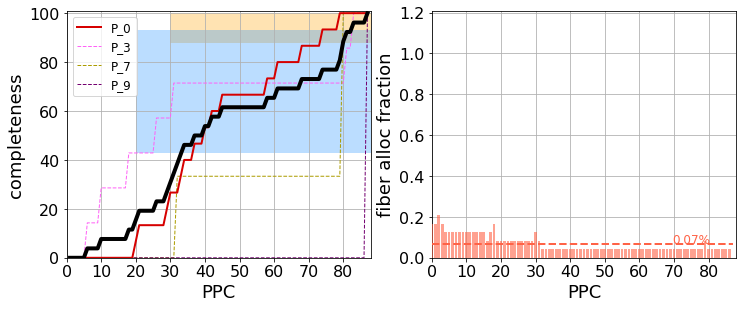

In [11]:
## INPUT: "input/z4qso_t.csv" z4 qso testing sample
#weight: conta--> science grade,>0; contb--> remaining time; contc--> local density
test1=execu([4.02,0.22,0.15],True,True)

##For the medium-resolution mode, PPP takes 24.22 sec.
#The total observation time you required is: 5.00 hours; 44.75 fiber hours
#The average fiber usage fraction: 0.37 %;
#There are 100.00% of the total pointings having fiber usage fraction less than 30%.


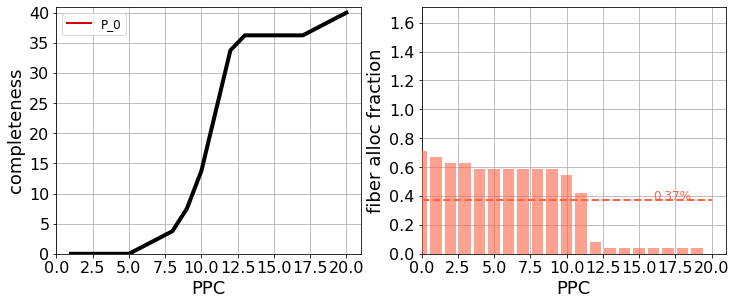

##For the low   -resolution mode, PPP takes 153.39 sec.
#The total observation time you required is: 62.75 hours; 2878.00 fiber hours
#The average fiber usage fraction: 1.92 %;
#There are 100.00% of the total pointings having fiber usage fraction less than 30%.


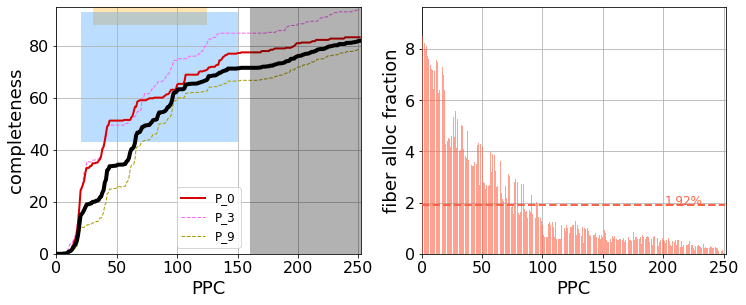

In [14]:
## INPUT: "input/cluster_t.csv" cluster testing sample
#weight: conta--> science grade,>0; contb--> remaining time; contc--> local density
test2=execu([4.02,0.22,0.15],True,True)

##For the medium-resolution mode, PPP takes 118.98 sec.
#The total observation time you required is: 45.25 hours; 7211.75 fiber hours
#The average fiber usage fraction: 6.66 %;
#There are 88.95% of the total pointings having fiber usage fraction less than 30%.


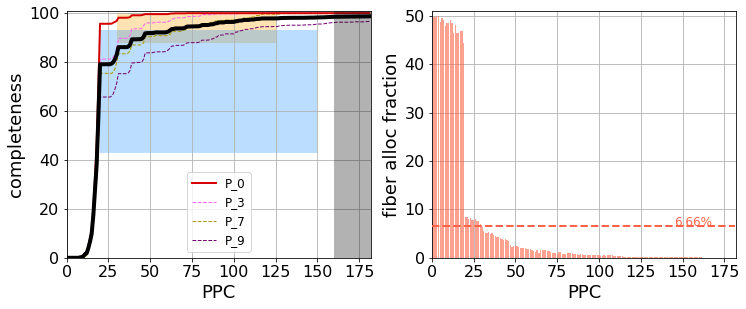

In [12]:
## INPUT: "input/star_t.csv" star testing sample
#weight: conta--> science grade,>0; contb--> remaining time; contc--> local density
test3=execu([4.02,0.22,0.15],True,True)